<a href="https://colab.research.google.com/github/kayeneii/Floodgate/blob/main/floodgate_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 4: Spatial Analysis & Modeling

- Import the FRI raster and river shapefile.

- Create a river proximity surface.

- Identify high-risk flood corridors.

- Quantify and visualize flood-prone areas.

In [23]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define base directory for project
base_dir = "/content/drive/MyDrive"

# Paths to exported files
fri_path = f"{base_dir}/floodgate_fri_geotiff.tif"
rivers_path = f"{base_dir}/GEE_exports/hydro_rivers_bbox.shp"

# Install necessary libraries (lightweight and prebuilt in Colab)
!pip install geopandas rasterio shapely matplotlib scipy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import the FRI raster and river shapefile.

In [24]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Load FRI raster
fri_src = rasterio.open(fri_path)
fri = fri_src.read(1)
print("FRI Raster CRS:", fri_src.crs)
print("Raster shape:", fri.shape)

FRI Raster CRS: EPSG:4326
Raster shape: (3713, 3712)


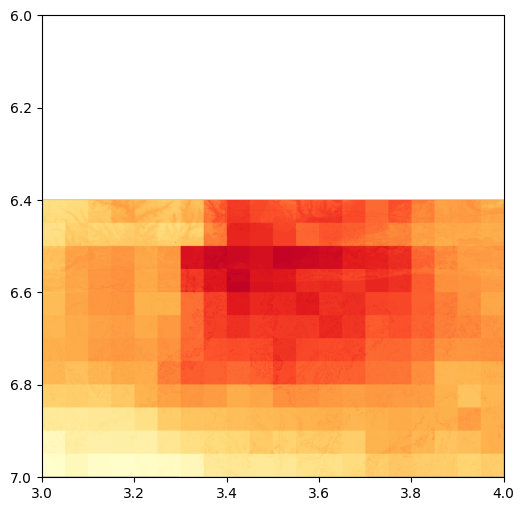

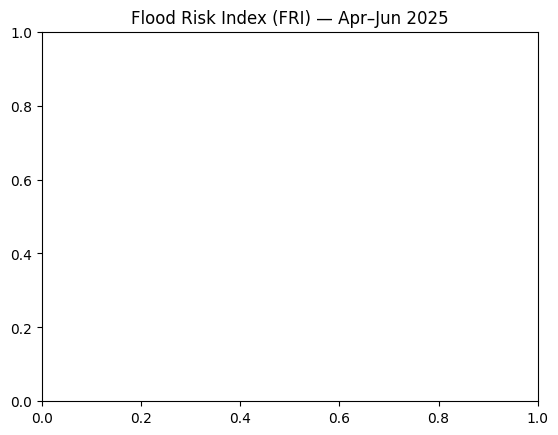

In [25]:
# Plot FRI
plt.figure(figsize=(8,6))
show(fri_src, cmap='YlOrRd')
plt.title("Flood Risk Index (FRI) — Apr–Jun 2025")
plt.show()

### 🧠Why the “Flood Risk Index” plot was blank

rasterio.plot.show() tries to render all bands of a raster.
If:

- the raster has a nodata value set, or
- the array is entirely masked with NaN in some tiles, or
- the raster is stored as float32 with normalization not applied (values between 0–1),

then show() sometimes suppresses the color scaling and displays a blank frame.

**FIX:** You can replace your plotting block with this version, which reads the data explicitly and handles masked/nodata cells.

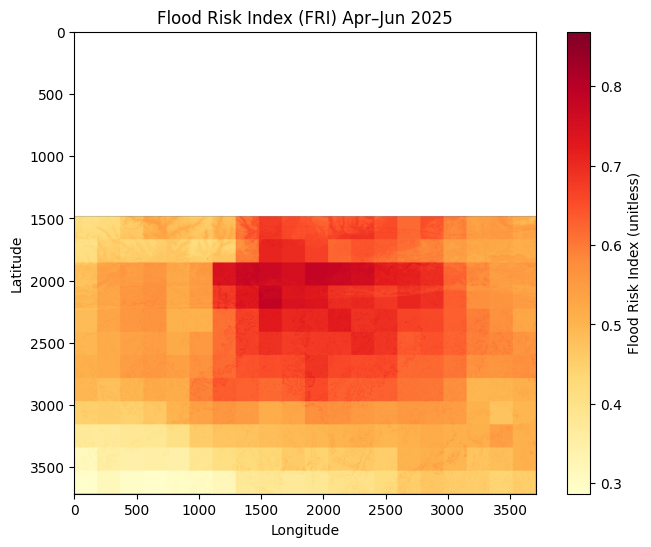

In [31]:
# Plot FRI correctly (handles NaN and nodata)
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

# Read raster band and mask nodata
fri_data = fri_src.read(1, masked=True)

plt.figure(figsize=(8,6))
plt.imshow(fri_data, cmap='YlOrRd', vmin=np.nanmin(fri_data), vmax=np.nanmax(fri_data))
plt.colorbar(label="Flood Risk Index (unitless)")
plt.title("Flood Risk Index (FRI) Apr–Jun 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [30]:
print("FRI min:", np.nanmin(fri_data))
print("FRI max:", np.nanmax(fri_data))
print("Nodata value:", fri_src.nodata)

FRI min: 0.28666666
FRI max: 0.8688664
Nodata value: None


Number of rivers: 661


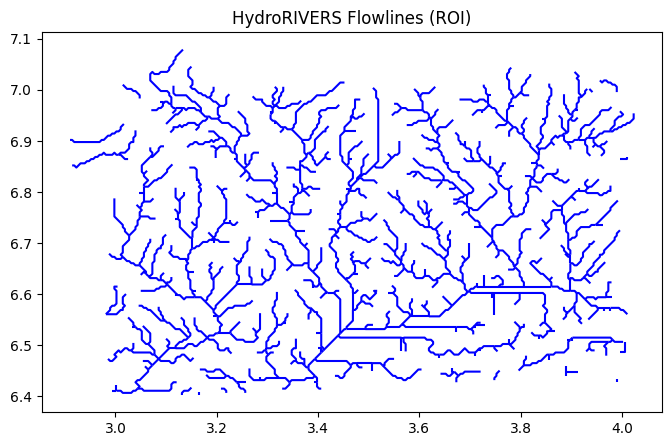

In [26]:
# Load river shapefile
rivers = gpd.read_file(rivers_path, encoding='ISO-8859-1')
print("Number of rivers:", len(rivers))
rivers.plot(figsize=(8,6), color='blue')
plt.title("HydroRIVERS Flowlines (ROI)")
plt.show()

### River proximity and flood corridor masking

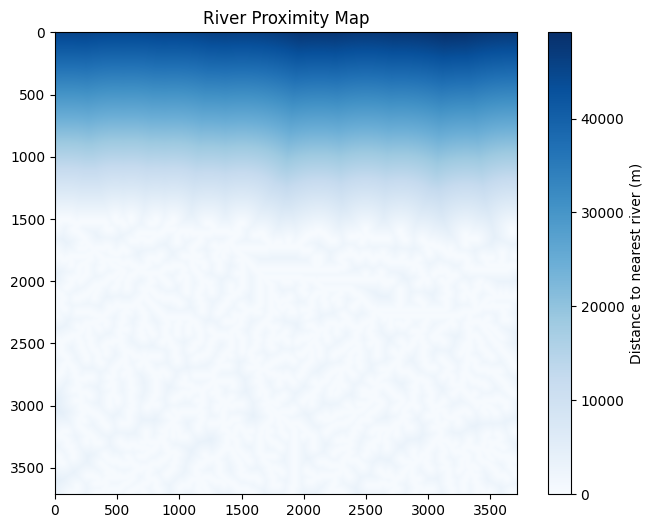

In [32]:
import numpy as np
from rasterio import features
from scipy.ndimage import distance_transform_edt

# Rasterize rivers (1 where rivers exist, 0 elsewhere)
rivers_raster = features.rasterize(
    [(geom, 1) for geom in rivers.geometry],
    out_shape=fri.shape,
    transform=fri_src.transform,
    fill=0,
    dtype='uint8'
)

# Compute Euclidean distance (pixels → meters)
dist_pixels = distance_transform_edt(1 - rivers_raster)
pixel_size = fri_src.transform[0]  # degrees or meters depending on CRS
dist_meters = dist_pixels * pixel_size * 111320  # convert degrees→meters if EPSG:4326

# Visualize proximity surface
plt.figure(figsize=(8,6))
plt.imshow(dist_meters, cmap='Blues')
plt.colorbar(label='Distance to nearest river (m)')
plt.title("River Proximity Map")
plt.show()

# Define flood corridors (<= 500m, <= 1000m)
corridors = {
    "500m": dist_meters <= 500,
    "1000m": dist_meters <= 1000
}

### Identify high-risk flood corridors by combining with FRI

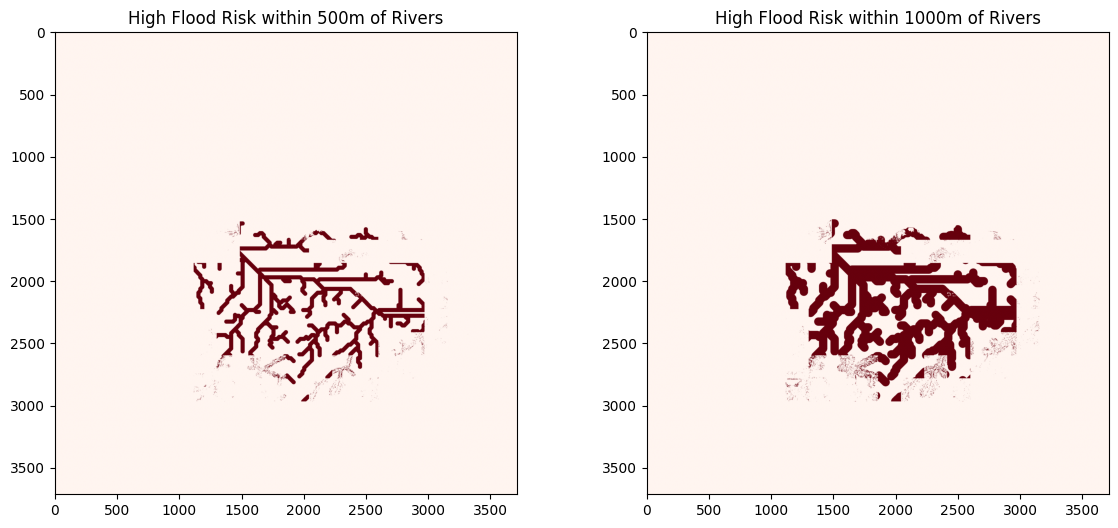

In [33]:
# Define a high-risk threshold (FRI normalized to 0–1, choose empirically)
high_risk_threshold = np.nanpercentile(fri, 80)  # top 20% risk
high_risk_mask = fri >= high_risk_threshold

# Combine high-risk + proximity masks
corridor_500 = np.logical_and(corridors["500m"], high_risk_mask)
corridor_1000 = np.logical_and(corridors["1000m"], high_risk_mask)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(corridor_500, cmap='Reds')
axes[0].set_title("High Flood Risk within 500m of Rivers")
axes[1].imshow(corridor_1000, cmap='Reds')
axes[1].set_title("High Flood Risk within 1000m of Rivers")
plt.show()

### Export flood corridor masks for cartography and QA in QGIS

In [35]:
from rasterio.transform import Affine

def export_mask(mask, filename):
    out_path = f"{base_dir}/{filename}.tif"
    profile = fri_src.profile
    profile.update(dtype=rasterio.uint8, count=1)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(mask.astype(rasterio.uint8), 1)
    print(f"Exported: {out_path}")

export_mask(corridor_500, "floodgate_flood_corridor_500m")
export_mask(corridor_1000, "floodgate_flood_corridor_1000m")

Exported: /content/drive/MyDrive/floodgate_flood_corridor_500m.tif
Exported: /content/drive/MyDrive/floodgate_flood_corridor_1000m.tif
